# **Initial Conditions for Multi-Soliton KdV**

When training a PINN to learn multi-soliton solutions (e.g., 2 or 3 solitons), we use a linear combination of individual solitons as the initial condition. This is an approximate solution (valid when solitons are far apart and don't interact).

For solitons to align properly before collision (so we can visualize the phase shifts due to the nonlinear interaction), we need to apply specific phase shifts to the linear combination. This notebook demonstrates how these shifts are computed and applied to the linear combination and compares them with the exact solution that we wish to compare to. 

In [11]:
import numpy as np
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'retina'

## **Implementation**

We define two key functions:
1. **`n_solitons()`** — the exact N-soliton solution (Hirota form)
2. **`linear_combination()`** — the linear superposition of individual solitons

In [ ]:
def n_solitons(n, x, t, k, delta):
    # exact n-soliton solution

    u = np.zeros_like(x)

    if n == 1:
        
        eta = k * (x - k**2 * t) + delta
        f   = 1.0 + np.exp(eta)
        fx  = k * np.exp(eta)
        fxx = k**2 * np.exp(eta)

        u = 2.0 * (f * fxx - fx**2) / f**2

    elif n == 2:

        k1, k2 = k
        delta1, delta2 = delta

        # Hirota two-soliton tau-function in double precision
        eta1 = k1 * (x - k1**2 * t) + delta1
        eta2 = k2 * (x - k2**2 * t) + delta2

        A12 = ((k1 - k2) / (k1 + k2)) ** 2

        exp1  = np.exp(eta1)
        exp2  = np.exp(eta2)
        exp12 = np.exp(eta1 + eta2)

        f = 1.0 + exp1 + exp2 + A12 * exp12
        fx = k1 * exp1 + k2 * exp2 + A12 * (k1 + k2) * exp12
        fxx = k1**2 * exp1 + k2**2 * exp2 + A12 * (k1 + k2)**2 * exp12

        u = 2.0 * (f * fxx - fx**2) / (f**2)

    elif n == 3:
        k1, k2, k3   = k
        d1, d2, d3   = delta

        eta1 = k1 * (x - k1**2 * t) + d1
        eta2 = k2 * (x - k2**2 * t) + d2
        eta3 = k3 * (x - k3**2 * t) + d3

        # interaction coefficients
        A12 = ((k1 - k2) / (k1 + k2))**2
        A13 = ((k1 - k3) / (k1 + k3))**2
        A23 = ((k2 - k3) / (k2 + k3))**2

        exp1   = np.exp(eta1)
        exp2   = np.exp(eta2)
        exp3   = np.exp(eta3)
        exp12  = np.exp(eta1 + eta2)
        exp13  = np.exp(eta1 + eta3)
        exp23  = np.exp(eta2 + eta3)
        exp123 = np.exp(eta1 + eta2 + eta3)

        # τ-function and its derivatives
        f   = (
            1.0
            + exp1 + exp2 + exp3
            + A12 * exp12 + A13 * exp13 + A23 * exp23
            + A12 * A13 * A23 * exp123
        )

        fx  = (
            k1 * exp1 + k2 * exp2 + k3 * exp3
            + A12 * (k1 + k2) * exp12
            + A13 * (k1 + k3) * exp13
            + A23 * (k2 + k3) * exp23
            + A12 * A13 * A23 * (k1 + k2 + k3) * exp123
        )

        fxx = (
            k1**2 * exp1 + k2**2 * exp2 + k3**2 * exp3
            + A12 * (k1 + k2)**2 * exp12
            + A13 * (k1 + k3)**2 * exp13
            + A23 * (k2 + k3)**2 * exp23
            + A12 * A13 * A23 * (k1 + k2 + k3)**2 * exp123
        )

        u = 2.0 * (f * fxx - fx**2) / f**2
        
    return u

In [13]:
def linear_combination(n, x, t, k, delta):
    # n = number of solitons
    u = np.zeros_like(x)
    for i in range(n):
        u += n_solitons(1, x, t, k[i], delta[i])
    return u

## **Examples**

We now compare these two forms for n = 1, 2 and 3. 

### **Single Soliton**

First, let's ensure that we get the expected result for the single soliton case. 

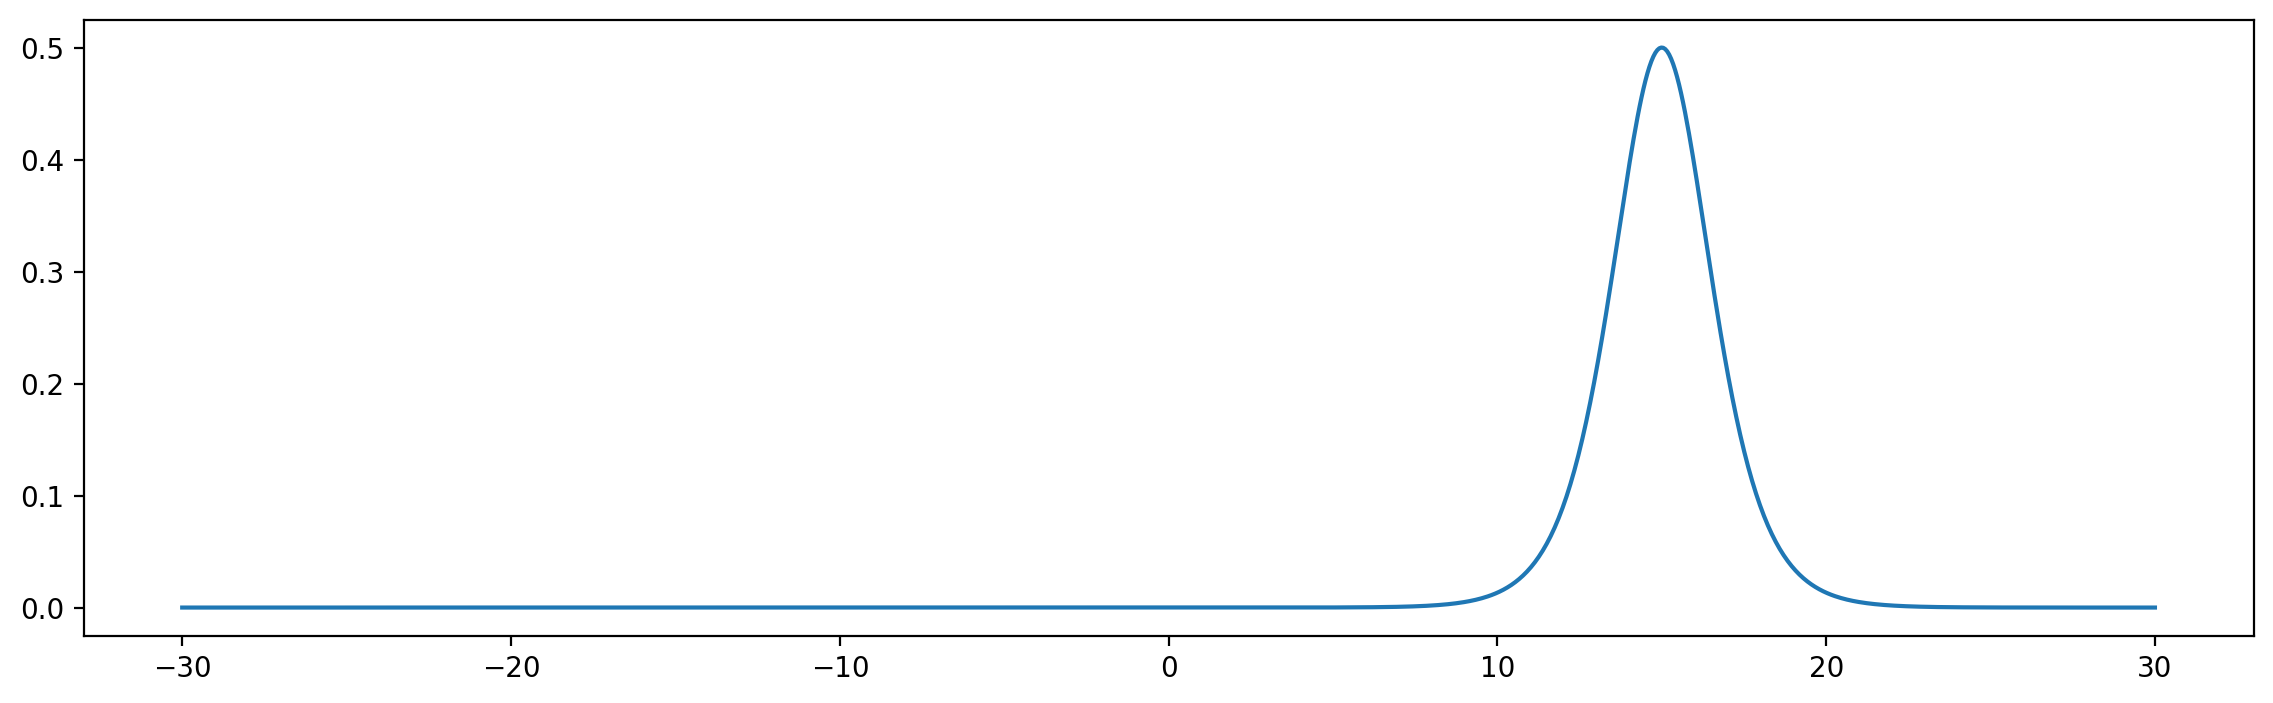

In [14]:
x = np.linspace(-30, 30, 1000)
t = 15
k = 1.0
delta = 0

u = n_solitons(1, x, t, k, delta)

plt.figure(figsize=(14, 4))
plt.plot(x, u)

### **Two Soliton**

For the two soliton case, we want the linear combination to align with the exact solution before the collision, such that we can visualize the phase shift for both of the solitons (in the true solution) after the collision. 

To do this, we shift the smaller/slower soliton of the linear combination by
$$\delta_2 = a_{12} = 2 \ln \left(\frac{k_1 - k_2}{k_1 + k_2}\right)$$

Speed ratio: 1.8257418583505538
[0.0, -2.4604880186243054]


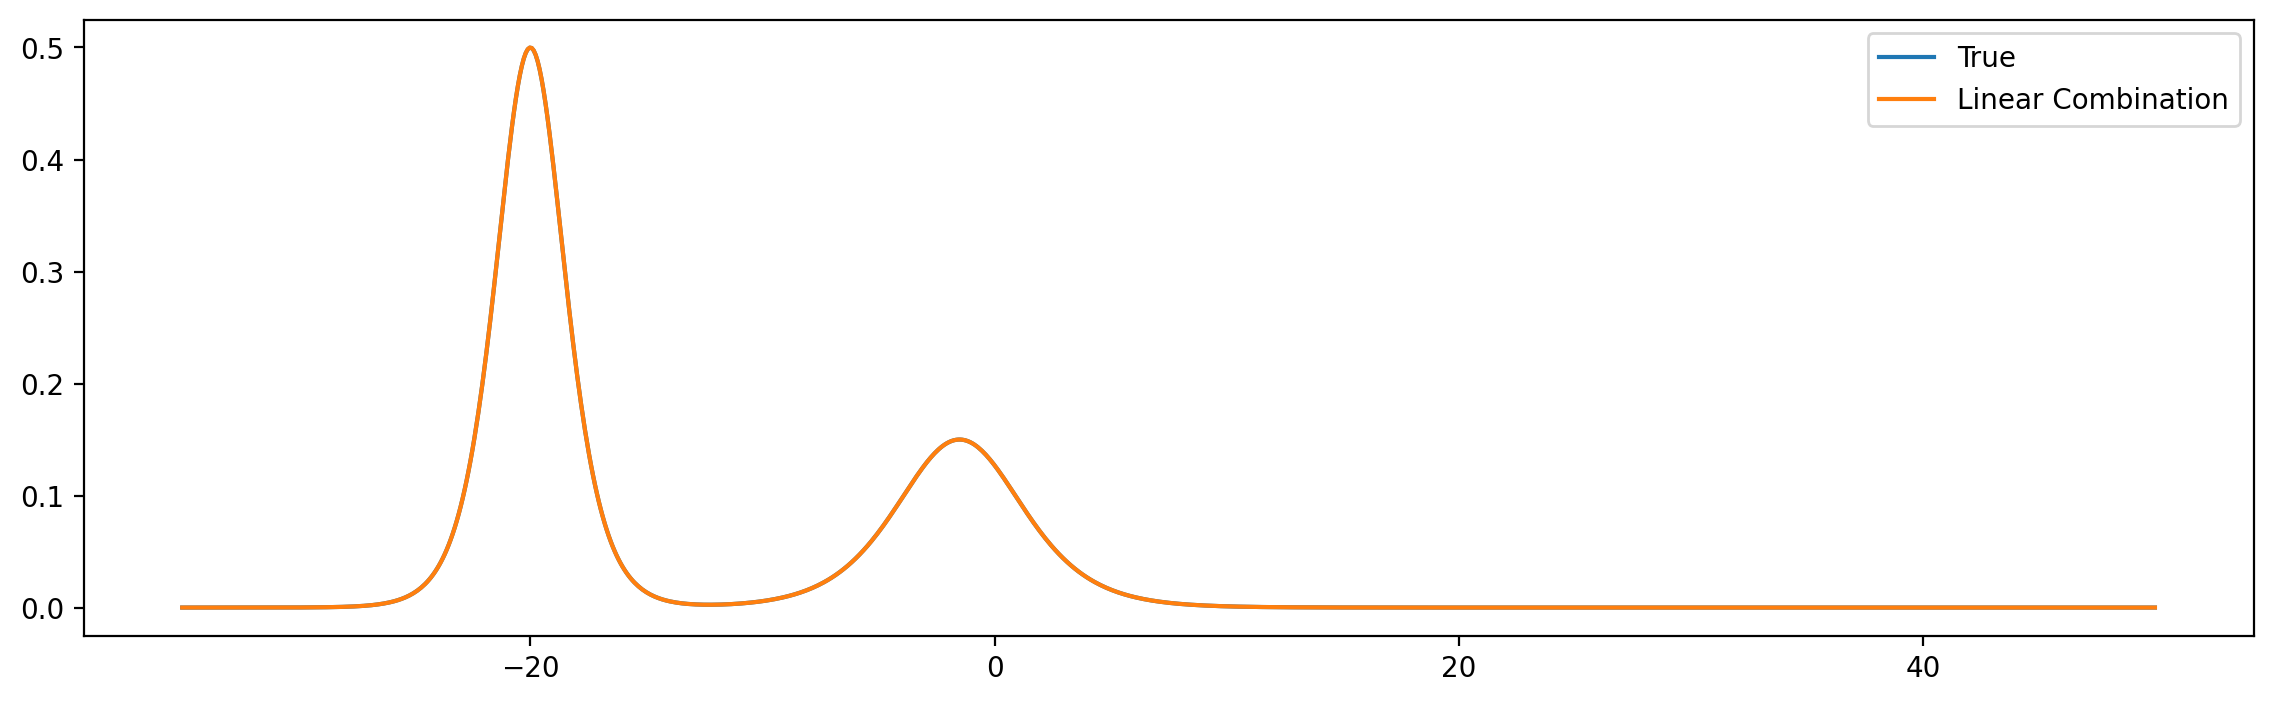

In [15]:
x = np.linspace(-35, 50, 1000)

k = [np.sqrt(4/4), np.sqrt(1.2/4)]
a12 = 2*np.log((k[0]-k[1])/(k[0]+k[1]))   # constant phase-shift term

print(f"Speed ratio: {k[0]/k[1]}")

delta_true  = [0.0, 0.0]      # for the exact 2-soliton
delta_naive = [0.0, a12]      # shift only the slow soliton
print(delta_naive)

t = -20
u_true = n_solitons(2, x, t, k, delta_true)
u_naive = linear_combination(2, x, t, k, delta_naive)

plt.figure(figsize=(14, 4))
plt.plot(x, u_true, label='True')
plt.plot(x, u_naive, label='Linear Combination')
plt.legend()
plt.show()

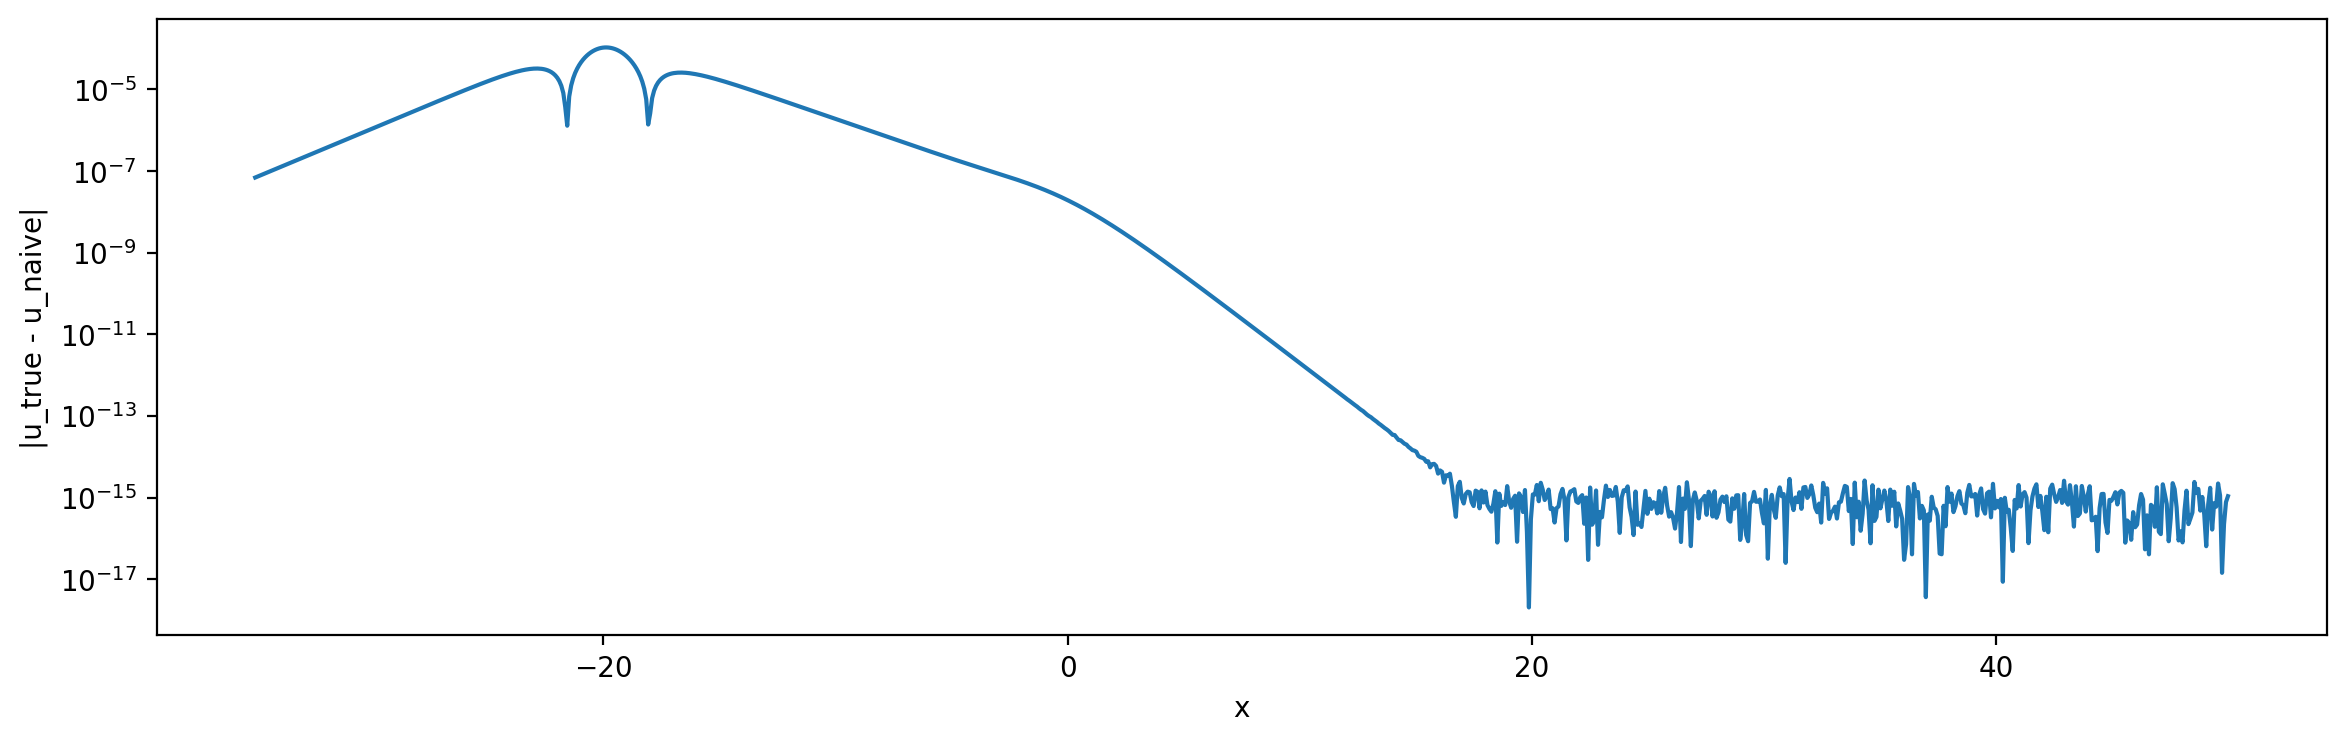

Mean difference: 5.029952932633298e-06


In [16]:
plt.figure(figsize=(14, 4))
plt.plot(x, np.abs(u_true - u_naive))
plt.yscale('log')
plt.xlabel('x')
plt.ylabel('|u_true - u_naive|')
plt.show()

# print mean difference between the two solutions
print(f"Mean difference: {np.mean(np.abs(u_true - u_naive))}")

### **Three Solitons**

Recall that 

$$a_{i j}=2 \ln \left(\frac{k_i-k_j}{k_i+k_j}\right), \quad \text{and assume} \quad k_1>k_2>k_3$$

For the three soliton case, similar to the two soliton case, we don't need to shift the fastest ($k_1$) crest. 

$$ \delta_1 = 0 \\
    \delta_2 = a_{12} \\
    \delta_3 = a_{13} + a_{23}$$

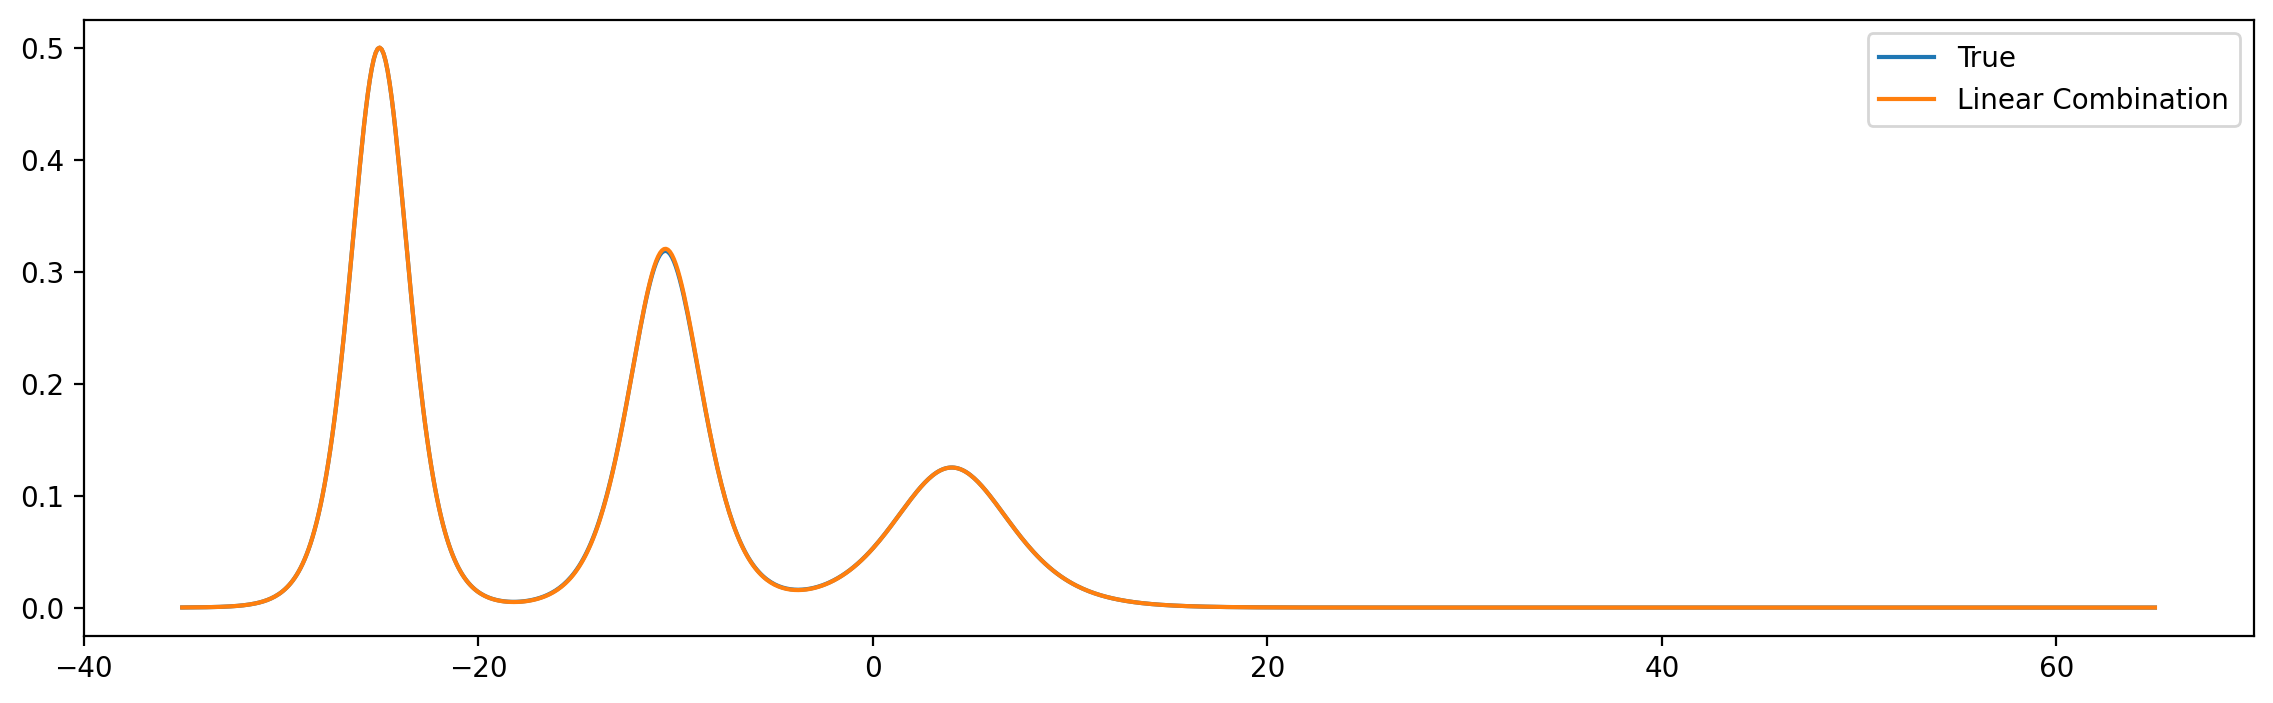

In [17]:
x = np.linspace(-35, 65, 1000)

k = [1, 0.8, 0.5]

def aij(ki, kj):
    return 2*np.log((ki - kj) / (ki + kj))

a12 = aij(k[0], k[1])
a13 = aij(k[0], k[2])
a23 = aij(k[1], k[2])

delta = [0.0, 0.0, 0.0]
delta_naive = [0.0, a12, a13 + a23] 

t = -25 # need to go between [-25, 50] to see the full behaviour (too large of a domain)
u_true = n_solitons(3, x, t, k, delta)
u_naive = linear_combination(3, x, t, k, delta_naive)

plt.figure(figsize=(14, 4))
plt.plot(x, u_true, label='True')
plt.plot(x, u_naive, label='Linear Combination')
plt.legend()
plt.show()

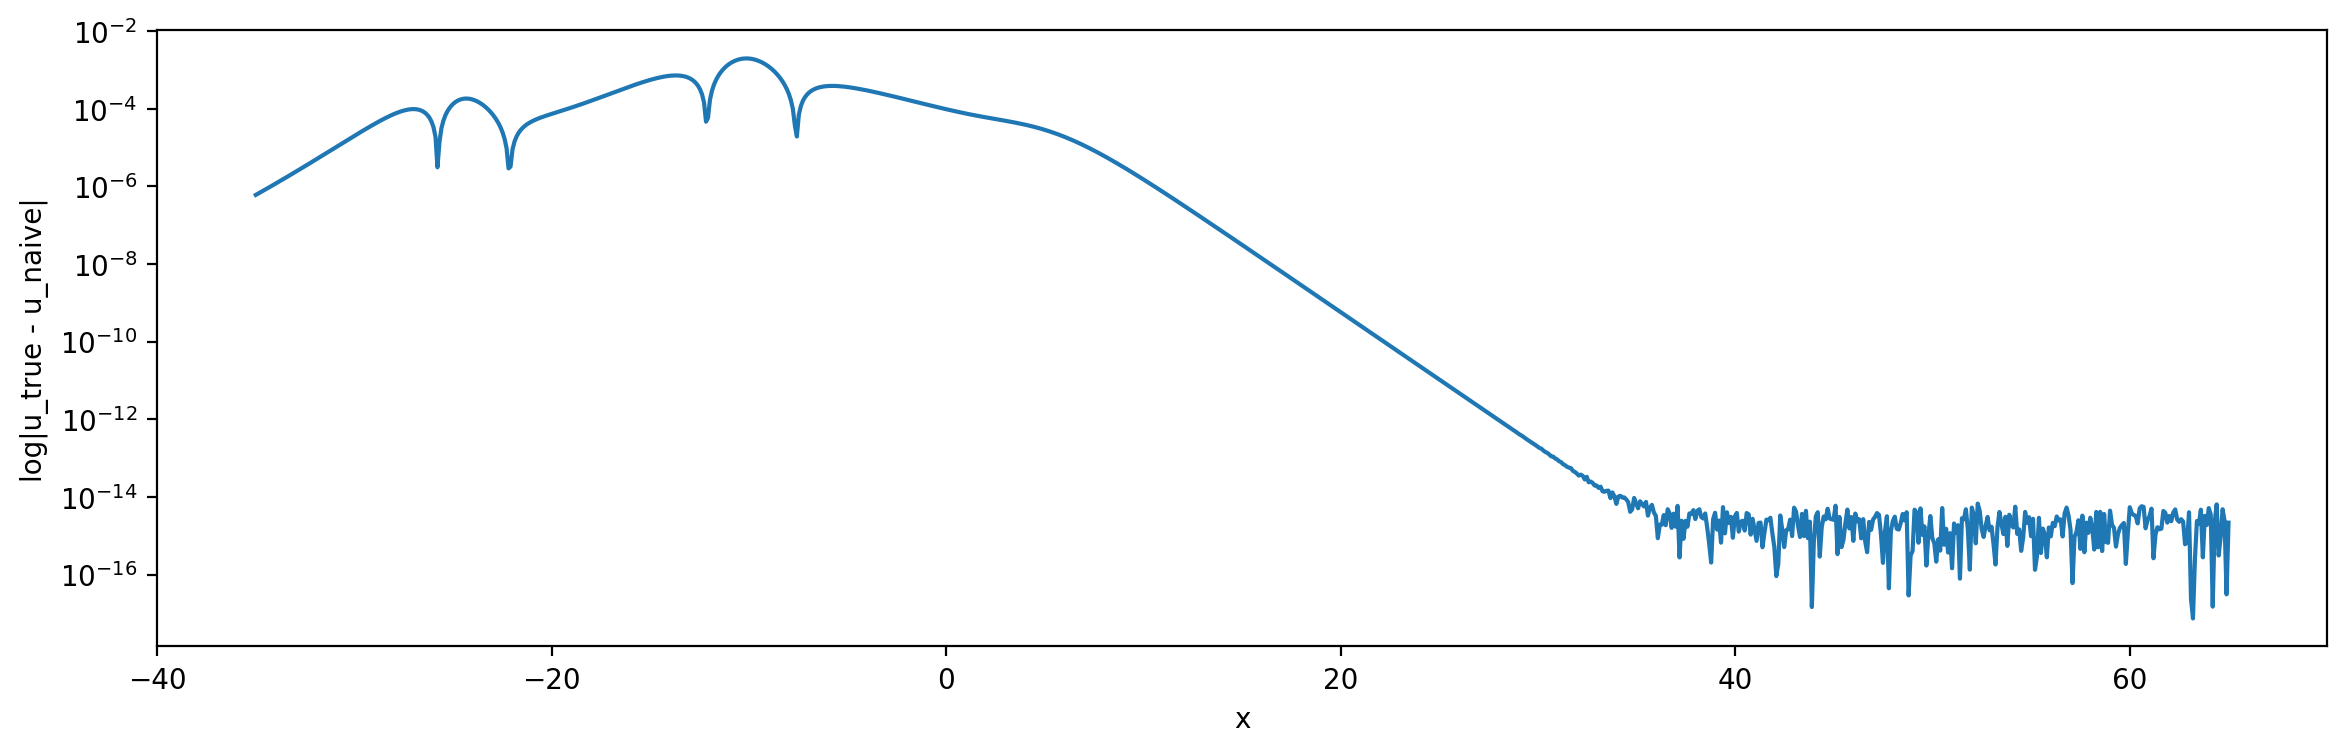

Mean difference: 0.00010749657294952875


In [18]:
plt.figure(figsize=(14, 4))
plt.plot(x, np.abs(u_true - u_naive))
plt.yscale('log')
plt.xlabel('x')
plt.ylabel('log|u_true - u_naive|')
plt.show()

# print mean difference between the two solutions
print(f"Mean difference: {np.mean(np.abs(u_true - u_naive))}")